<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/Prac_13_Binary_Classification_Machine_Learning_Case_Study_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# Chapter 13: Binary Classification Machine Learning Case Study Project

How do you work through a predictive modeling machine learning problem end-to-end? In this lesson you will work through a case study classification predictive modeling problem in Python including each step of the applied machine learning process. After completing this project, you will know:
- How to work through a classification predictive modeling problem end-to-end.
- How to use data transforms to improve model performance.
- How to use algorithm tuning to improve model performance.
- How to use ensemble methods and tuning of ensemble methods to improve model performance.

## Problem Definition
The focus of this project will be the [Sonar Mines vs Rocks dataset](https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks) . The problem is to predict metal or rock objects from sonar return data. Each pattern is a set of 60 numbers in the range 0.0 to 1.0. Each number represents the energy within a particular frequency band, integrated over a certain period of time. The label associated with each record contains the letter R if
the object is a rock and M if it is a mine (metal cylinder). The numbers in the labels are in increasing order of aspect angle, but they do not encode the angle directly.

## Load the Dataset

Let’s start off by loading the libraries required for this project.

---
**Load Libraries**

---

In [30]:
# Load libraries
import numpy
from matplotlib import pyplot
import pandas as pd
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

---
**Load Dataset**

---

In [31]:
!wget -O /content/sample_data/sonar.all-data https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/sonar.all-data

--2025-04-14 07:11:23--  https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/sonar.all-data
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 87776 (86K) [text/plain]
Saving to: ‘/content/sample_data/sonar.all-data’

/content/sample_dat 100%[===================>]  85.72K  --.-KB/s    in 0.01s   

2025-04-14 07:11:23 (6.91 MB/s) - ‘/content/sample_data/sonar.all-data’ saved [87776/87776]



In [32]:
# Load dataset
filename = '/content/sample_data/sonar.all-data'
data = read_csv(filename, header=None)

You can see that we are not specifying the names of the attributes this time. This is because
other than the class attribute (the last column), the variables do not have meaningful names.
We also indicate that there is no header information, this is to avoid file loading code taking the
first record as the column names. Now that we have the dataset loaded we can take a look at it.

## Summarize the Dataset

Let’s take a closer look at our loaded data. We can now take a closer look at our loaded data. We can get a quick idea of how many instances (rows) and how many attributes (columns) the data contains with the shape property.

---
**Data Shape**

---

In [33]:
# shape
print(data.shape)

(208, 61)


We have 208 instances to work with and can confirm the data has 61 attributes including the class attribute.

Let’s also look at the data types of each attribute.

In [34]:
# types
set_option('display.max_rows', 500)
print(data.dtypes)

0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
12    float64
13    float64
14    float64
15    float64
16    float64
17    float64
18    float64
19    float64
20    float64
21    float64
22    float64
23    float64
24    float64
25    float64
26    float64
27    float64
28    float64
29    float64
30    float64
31    float64
32    float64
33    float64
34    float64
35    float64
36    float64
37    float64
38    float64
39    float64
40    float64
41    float64
42    float64
43    float64
44    float64
45    float64
46    float64
47    float64
48    float64
49    float64
50    float64
51    float64
52    float64
53    float64
54    float64
55    float64
56    float64
57    float64
58    float64
59    float64
60     object
dtype: object


We can see that all of the attributes are numeric (float) and that the class value has been
read in as an object.

---
**Show first rows**

---

It is also always a good idea to actually eyeball your data. Let’s now take a peek at the first 20 rows of the data.

In [35]:
# head
print(data.head(20))

       0      1      2      3      4      5      6      7      8      9   ...     51     52  \
0   0.020  0.037  0.043  0.021  0.095  0.099  0.154  0.160  0.311  0.211  ...  0.003  0.006   
1   0.045  0.052  0.084  0.069  0.118  0.258  0.216  0.348  0.334  0.287  ...  0.008  0.009   
2   0.026  0.058  0.110  0.108  0.097  0.228  0.243  0.377  0.560  0.619  ...  0.023  0.017   
3   0.010  0.017  0.062  0.021  0.021  0.037  0.110  0.128  0.060  0.126  ...  0.012  0.004   
4   0.076  0.067  0.048  0.039  0.059  0.065  0.121  0.247  0.356  0.446  ...  0.003  0.005   
5   0.029  0.045  0.028  0.017  0.038  0.099  0.120  0.183  0.210  0.304  ...  0.004  0.001   
6   0.032  0.096  0.132  0.141  0.167  0.171  0.073  0.140  0.208  0.351  ...  0.020  0.025   
7   0.052  0.055  0.084  0.032  0.116  0.092  0.103  0.061  0.146  0.284  ...  0.008  0.012   
8   0.022  0.037  0.048  0.048  0.065  0.059  0.075  0.010  0.068  0.149  ...  0.015  0.013   
9   0.016  0.017  0.035  0.007  0.019  0.067  0.10

This does not show all of the columns, but we can see all of the data has the same scale. We
can also see that the class attribute (60) has string values (R) and possibly (M) as the previous description have mentioned.

---
**Statistical Summary**

---

Now we can take a look at a summary of each attribute. This includes the count, mean, the min and max values as well as some percentiles.



In [36]:
# Statistical Summary
pd.set_option('display.precision', 3)
print(pd.DataFrame(data).describe())

            0          1        2        3        4        5        6        7        8        9   \
count  208.000  2.080e+02  208.000  208.000  208.000  208.000  208.000  208.000  208.000  208.000   
mean     0.029  3.844e-02    0.044    0.054    0.075    0.105    0.122    0.135    0.178    0.208   
std      0.023  3.296e-02    0.038    0.047    0.056    0.059    0.062    0.085    0.118    0.134   
min      0.002  6.000e-04    0.002    0.006    0.007    0.010    0.003    0.005    0.007    0.011   
25%      0.013  1.645e-02    0.019    0.024    0.038    0.067    0.081    0.080    0.097    0.111   
50%      0.023  3.080e-02    0.034    0.044    0.062    0.092    0.107    0.112    0.152    0.182   
75%      0.036  4.795e-02    0.058    0.065    0.100    0.134    0.154    0.170    0.233    0.269   
max      0.137  2.339e-01    0.306    0.426    0.401    0.382    0.373    0.459    0.683    0.711   

       ...       50         51         52       53         54         55         56       

Again, as we expect, the data has the same range, but interestingly differing mean values. There may be some benefit from standardizing the data.

---
**Balance Beetween Class**

---

Let’s take a quick look at the breakdown of class values.

In [37]:
# class distribution
print(data.groupby(60).size())

60
M    111
R     97
dtype: int64


## Data Visualization

We now have a basic idea about the data. We need to extend this with some visualizations. We
are going to look at two types of plots:
- Univariate plots to better understand each attribute.
- Multivariate plots to better understand the relationships between attributes.


---
**Univariate Plots: Histogram**

---

Let’s look at visualizations of individual attributes. It is often useful to look at your data
using multiple different visualizations in order to spark ideas. Let’s look at histograms of each
attribute to get a sense of the data distributions.

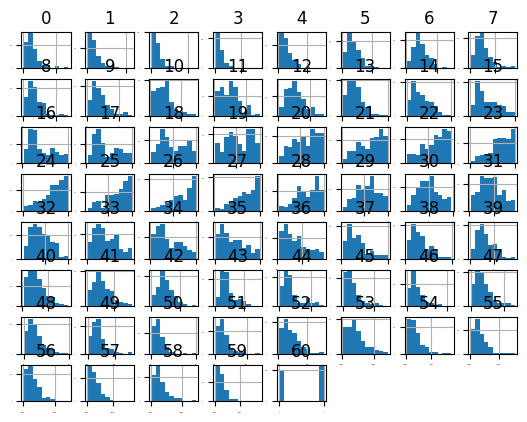

In [42]:
# histograms
data.hist(sharex=False, sharey=False, xlabelsize=1, ylabelsize=1)
pyplot.show()

We can see that there are a lot of Gaussian-like distributions and perhaps some exponential like distributions for other attributes.

---
**Univariate Plots: Density**

---


Let’s look at the same distributions using density plots that smooth them out a bit.

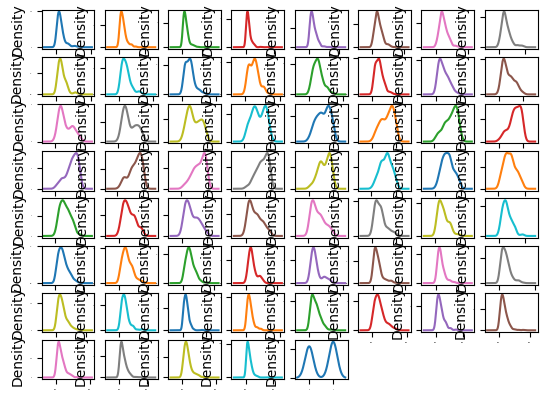

In [47]:
# density
data.plot(kind='density', subplots=True, layout=(8,8), sharex=False, legend=False,
fontsize=1)
pyplot.show()

This is useful, you can see that many of the attributes have a skewed distribution. A power transform like a Box-Cox transform that can correct for the skew in distributions might be useful.

---
**Univariate Plots: Whisker Plot**

---

Let’s look at the data with box and whisker plots of each attribute.

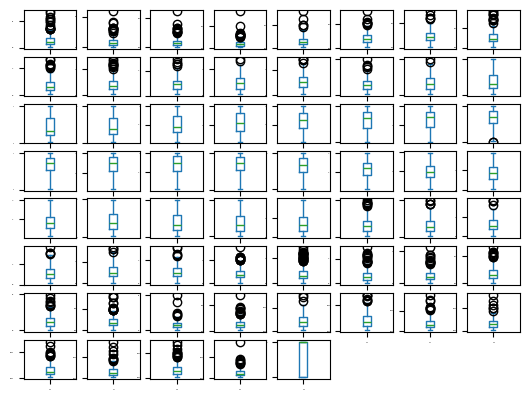

In [48]:
# box and whisker plots
data.plot(kind='box', subplots=True, layout=(8,8), sharex=False, sharey=False,
fontsize=1)
pyplot.show()

We can see that attributes do have quite different spreads. Given the scales are the same, it
may suggest some benefit in standardizing the data for modeling to get all of the means lined
up.

---
**Multivariate Plots:Correlation**

---

You need to convert the class labels in the last column to numeric values before calling the corr function. You can do this using a label encoding technique, where you assign a unique numeric value to each distinct class label. For example, you can replace 'R' with 0 and 'M' with 1.

In [39]:
# correlation
# Convert 'R' and 'M' to numeric values
data[60] = data[60].map({'R': 0, 'M': 1})
# set precision and calculate the correlation
pd.set_option('display.precision', 2)
print(data.corr(method='pearson'))

      0         1     2         3         4     5         6     7         8         9   ...  \
0   1.00  7.36e-01  0.57  4.91e-01  3.45e-01  0.24  2.61e-01  0.36  3.53e-01  3.18e-01  ...   
1   0.74  1.00e+00  0.78  6.07e-01  4.20e-01  0.33  2.79e-01  0.33  3.17e-01  2.71e-01  ...   
2   0.57  7.80e-01  1.00  7.82e-01  5.46e-01  0.35  1.90e-01  0.24  2.53e-01  2.20e-01  ...   
3   0.49  6.07e-01  0.78  1.00e+00  7.27e-01  0.35  2.46e-01  0.25  2.47e-01  2.38e-01  ...   
4   0.34  4.20e-01  0.55  7.27e-01  1.00e+00  0.60  3.35e-01  0.20  1.78e-01  1.83e-01  ...   
5   0.24  3.32e-01  0.35  3.53e-01  5.97e-01  1.00  7.03e-01  0.47  3.28e-01  2.89e-01  ...   
6   0.26  2.79e-01  0.19  2.46e-01  3.35e-01  0.70  1.00e+00  0.68  4.71e-01  4.25e-01  ...   
7   0.36  3.35e-01  0.24  2.47e-01  2.04e-01  0.47  6.76e-01  1.00  7.79e-01  6.53e-01  ...   
8   0.35  3.17e-01  0.25  2.47e-01  1.78e-01  0.33  4.71e-01  0.78  1.00e+00  8.77e-01  ...   
9   0.32  2.71e-01  0.22  2.38e-01  1.83e-01  0.29

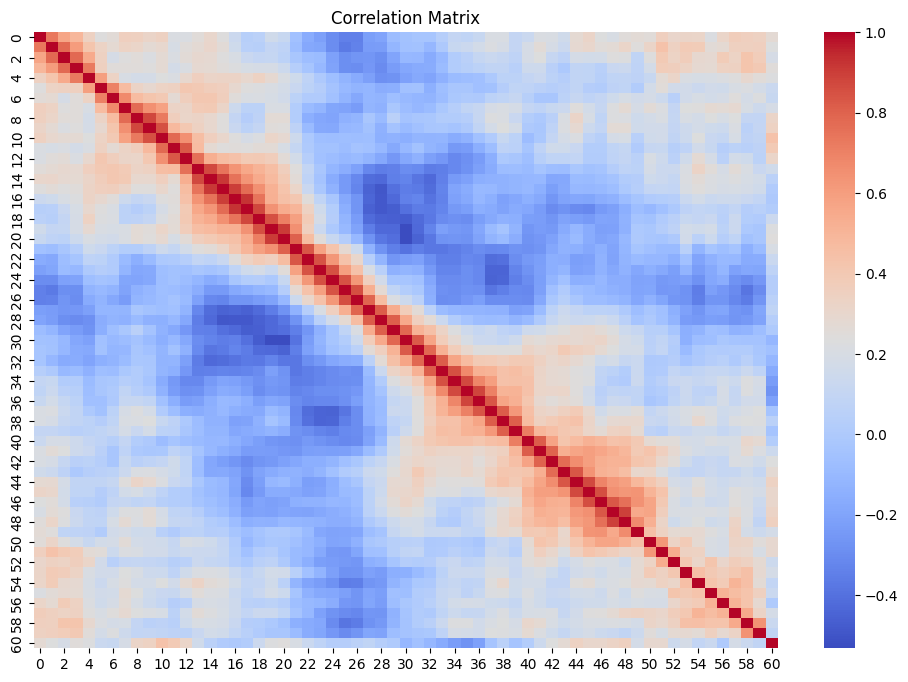

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting correlation matrix as a heatmap without numbers
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm', fmt='.2f')  # Set annot=False to hide numbers
plt.title("Correlation Matrix")
plt.show()

The heatmap visualization of the correlation matrix, where the color intensity represents the strength and direction of the correlation between variables.


1. **Diagonal (bright red)**  
   - Each feature is perfectly correlated with itself → correlation = 1.  
   - That’s why the diagonal is deep red.

2. **Correlated blocks**
   - Features in the ranges **0–20** and **40–60** show **clusters of high positive correlation**.
   - Some areas show **strong negative correlation** (blue), e.g., between middle and upper feature ranges.

3. **Low correlation in general**
   - Many features show low pairwise correlation → this indicates **feature independence**, which is good for machine learning.




